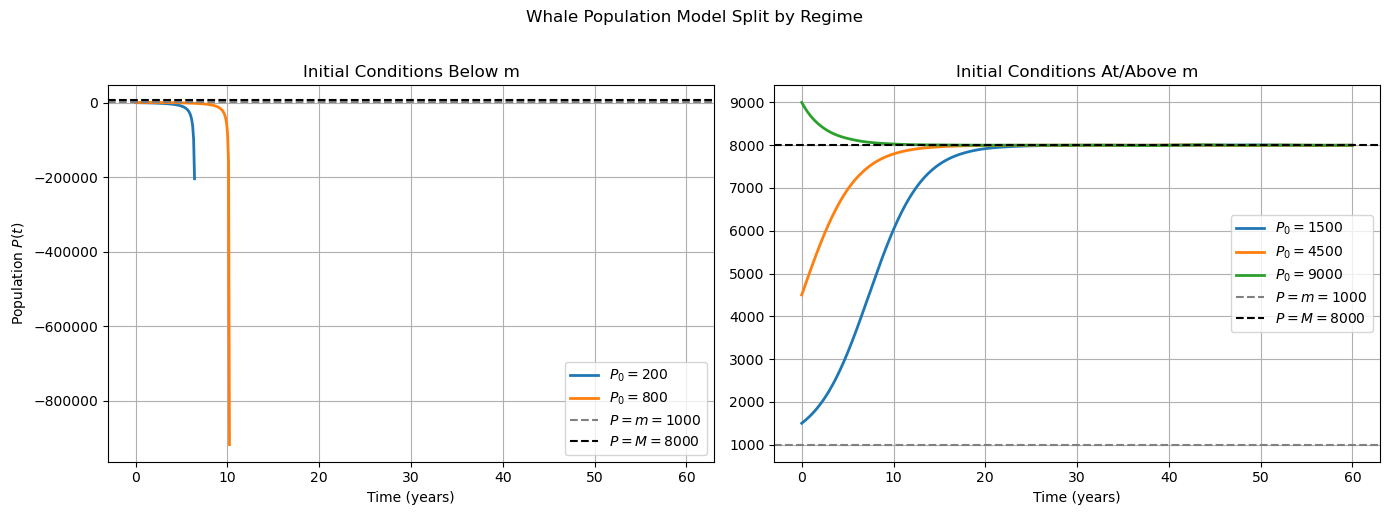

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
k = 0.00005
M = 8000
m = 1000

def whale_model(t, P, k, M, m):
    dPdt = k * (M - P[0]) * (P[0] - m)
    return [dPdt]

t_span = (0, 60)
t_eval = np.linspace(*t_span, 600)

# Initial params
P0_values = [200, 800, 1500, 4500, 9000]
P0_below = [P0 for P0 in P0_values if P0 < m]
P0_above = [P0 for P0 in P0_values if P0 >= m]

# Solve once and store for reuse
solutions = {}
for P0 in P0_values:
    sol = solve_ivp(whale_model, t_span, [P0], args=(k, M, m), t_eval=t_eval)
    solutions[P0] = sol

# Split view: trajectories below m vs at/above m I had to do this since it was hard to see the ones below m when plotted together with the ones above m
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for P0 in P0_below:
    sol = solutions[P0]
    axes[0].plot(sol.t, sol.y[0], linewidth=2, label=f"$P_0={P0}$")
axes[0].axhline(m, linestyle='--', color='gray', label=r"$P=m=1000$")
axes[0].axhline(M, linestyle='--', color='black', label=r"$P=M=8000$")
axes[0].set_title("Initial Conditions Below m")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Population $P(t)$")
axes[0].grid(True)
axes[0].legend()

for P0 in P0_above:
    sol = solutions[P0]
    axes[1].plot(sol.t, sol.y[0], linewidth=2, label=f"$P_0={P0}$")
axes[1].axhline(m, linestyle='--', color='gray', label=r"$P=m=1000$")
axes[1].axhline(M, linestyle='--', color='black', label=r"$P=M=8000$")
axes[1].set_title("Initial Conditions At/Above m")
axes[1].set_xlabel("Time (years)")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Whale Population Model Split by Regime", y=1.02)
plt.tight_layout()
plt.show()

The simulations match the three regimes from Problem 1(a). When \(P0<m\), the population decreases toward extinction, which happens for \(P0=200\) and \(P0=800\). When \(m<P0<M\), the population increases toward the carrying capacity \(M\), which happens for \(P0=1500\) and \(P0=4500\). When \(P0>M\), the population decreases toward \(M\), which happens for \(P0=9000\). This agrees with the sign analysis from the differential equation.

In [7]:
# Use the trajectory with P0 = 1500
sol_1500 = solutions[1500]

P_target = 0.99 * M   # 99% of carrying capacity
P_values = sol_1500.y[0]
t_values = sol_1500.t

# Find the first time P(t) reaches or exceeds 99% of M
index = np.where(P_values >= P_target)[0][0]
t_99 = t_values[index]

print(f"99% of M is {P_target:.0f}")
print(f"P(t) first reaches 99% of M at approximately t = {t_99:.2f} years.")

99% of M is 7920
P(t) first reaches 99% of M at approximately t = 20.03 years.


For \(P_0=1500\), I estimated the time when the population reaches \(99\%\) of the carrying capacity by finding the first time in the solution where \(P(t) 0.99M\). Since \(M=8000\), the target value is \(0.99M=7920\). Using the computed solution values, this occurs at approximately \(t=20.03\) years.